In [1]:
# Context Ladder
# prompting, to RAG, to agents, and finally to fine-tuning, capability increases—but so do cost, complexity and risk.

# 4 practical lenses: Capability, Cost, Control and Compliance.

# Imagine a Walmart manager saying:
#     ‘Here are 500 lines of incident information. Give me the top five recurring causes, classify their severity, and give me the result in a standard format.’
# reusable framework called CRAFT

# Can prompting solve this, or do we genuinely need to invest in something more complex?

# What does this cost at Walmart scale?
# Should we build it, buy it or partner?
# What happens when thousands or millions of requests arrive?
# How do caching, model routing and token economics affect the bill?
# What KPIs should we monitor?
# What guardrails and governance do we need?
# And why do so many impressive AI pilots never actually reach production?

In [2]:
# Day 1: Understand AI.
# Day 2: Instruct AI.
# Day 3: Give AI knowledge and connections.
# Day 4: Allow AI to act.
# Day 5: Decide whether the whole thing is worth building and scaling.

In [3]:
# Day1:

# What is Generative AI?
# What is a Large Language Model, and what is it actually doing when it answers you?
# How LLMs generate answers: tokens, prediction, context, and why responses are probabilistic
# How AI models are made: Pre-training
# How AI models are made: Fine-tuning
# How AI models are made: RLHF
# The Model Landscape: ChatGPT vs Claude vs Gemini
# How Engineering Managers should compare models for a real business decision
# Where models break: Hallucination
# Why AI can confidently make things up, and how to reduce hallucination
# Where models break: Bias
# Limits of Generative AI that Engineering Managers must design around
# Data Safety and Privacy: What happens when employees paste company data into AI tools?
# The Context Ladder: Overview
# Context Ladder Stage 1: Prompt Engineering
# Context Ladder Stage 2: RAG + MCP
# Context Ladder Stage 3: AI Agents
# Context Ladder Stage 4: Fine-tuning / PEFT
# The Context Ladder Rule: Climb only when the lower rung cannot solve the problem
# How to decide which Context Ladder approach a business problem actually needs
# The 4 C’s of Model Choice: Overview
# Capability — Can the model actually do the job?
# Cost — What will this solution cost at scale?
# Control — How much control do we have over outputs, data, and behavior?
# Compliance — Is the solution acceptable from privacy, security, legal, and governance perspectives?
# Using the 4 C’s to compare ChatGPT, Claude, and Gemini
# Live Comparison: Run the same Walmart task across ChatGPT, Claude, and Gemini
# Where each model shines and where each model struggles
# When does model choice actually matter, and when does it not matter much?
# Day 1 Decision Summary: Which AI approach should I choose for my Walmart use case?
# Day 1 Leadership Recap: Shared AI vocabulary every Engineering Manager should leave with

In [4]:
# Topic 1: What is Generative AI?

# Generative AI is a type of AI that can create new content based on what we ask it to do. That content could be text, images, summaries, code, documents, ideas, or even a draft response.

# For example, if I ask a traditional software system, ‘What is the price of this product?’, it may look up the price in a database and return it.

# But if I ask Generative AI, ‘Create a customer-friendly explanation of why this product is useful for a family of four,’ it can generate a completely new response for me.

# Walmart:
# It can take a long production incident log and generate a simple incident summary for leadership.
# It can take product information and draft a customer-friendly product description.
# It can help an engineer understand unfamiliar code.
# It can summarize policy documents.
# It can even help a support team prepare a first draft of a response to a customer issue.

# Generative AI creates new content from instructions and context. Its value comes from how well we give it the right context, and its risk comes from assuming that generated content is automatically correct.

# Q. If I ask AI to ‘summarize 50 pages of supplier guidelines into five action points,’ is that a good Generative AI use case?
# A. Yes

# Q. If I ask AI, ‘What is the exact live inventory of iPhones in a specific Walmart store right now?’ can the model reliably answer that by itself?
# A. No. It needs access to a live system or trusted data source.

In [5]:
# Topic 2: What is a Large Language Model, and what is it actually doing when it answers you?

# An LLM does not think about language exactly the way a human does. It predicts what should come next based on patterns it has learned.

# My name is Dr. Darshan Ingle and I am a data scientist.
# Tokens: 16
# Characters: 55

# मेरा नाम डॉ. दर्शन इंगले है और मैं एक डेटा साइंटिस्ट हूँ।
# Tokens: 19
# Characters: 57

# ನನ್ನ ಹೆಸರು ಡಾ. ದರ್ಶನ್ ಇಂಗ್ಲೆ ಮತ್ತು ನಾನು ಡೇಟಾ ಸೈಂಟಿಸ್ಟ್ ಆಗಿದ್ದೇನೆ.
# Tokens: 27
# Characters: 65

# 我叫 Darshan Ingle 博士，是一名資料科學家。
# Tokens: 16
# Characters: 29

# Key Points:
# First, an LLM is trained on large amounts of language and learns patterns.
# Second, when it responds, it generates output one token at a time.
# Third, fluent language does not guarantee factual correctness.
# Fourth, the quality of the answer depends heavily on the context you provide.
# Fifth, an LLM does not automatically know Walmart’s live or private information unless we connect it to trusted sources.

# Do not ask only, ‘How smart is the model?’ Ask, ‘What context does the model have, and how trustworthy is that context?’”

In [6]:
# Topic 3: How LLMs Generate Answers — Tokens, Prediction, Context, and Why Responses Are Probabilistic

# Tokens — the model does not see language exactly the way we do
# LLMs read and generate text in tokens, not in complete human thoughts.

# Prediction — the model generates one step at a time
# Prompt → predict next token → add it to the context → predict the next token → repeat.”

# Context — what the model sees changes what it generates

# A common misconception is:
#     ‘If I ask exactly the same question, the model should always give exactly the same answer.’
# Not necessarily.
# LLMs are generative systems.

# Do not treat an LLM like a fixed rules engine. Treat it as a probabilistic system whose output depends on context, constraints, and the level of control you design around it.

In [7]:
# Text Completions

# !pip install openai -q
# q - quiet installation

import openai

# Print openai version
print(openai.__version__)

3.16.2


In [8]:
# Two types of LLMs:
# 1. Open Source LLMs
# They are free. You can download it on your computer and use it freely. Size of LLM min: 5GB max: 100GB
# Macbook Pro M3: 16GB (VS Code, Zoom, Macbook oS, Web Camera, etc.) -> 5GB of 16GB + 5GB LLM = 10GB
# Time to predict: 15-20secs
# You need a strong computer to run them. You need a powerful GPU to run them. You need a lot of RAM to run them. You need a lot of storage to run them.

# 2. Commercial LLMs: OpenAI, Anthropic, Cohere, etc.
# They are paid. You need to pay to use them.
# The models are on OpenAI servers. You just cannot download it.

In [9]:
from dotenv import load_dotenv
import os
load_dotenv()
openai.api_key = os.getenv("OPENAI_API_KEY")

In [11]:
from openai import OpenAI
client = OpenAI(api_key=openai.api_key)

completion = client.chat.completions.create(
    model="gpt-5.5",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "Write a poem about the beauty of nature."}
    ]
)

# print(completion)
print(completion.choices[0].message.content)

# There are 3 types of messages:
# 1. user - I am the user or whosoever is asking a question to the GPT model is called as the user.
# 2. assistant - GPT model is the assistant.
# 3. system - this message is the aura or the persona, which you want the GPT model to adopt while answering the question. It is optional but it can help in getting better answers from the model.

Beneath the hush of morning’s glow,  
The rivers wake and silver flow,  
While mountains lift their ancient eyes  
To greet the soft, unfolding skies.  

The meadow wears a coat of dew,  
Each blade of grass a jeweled hue,  
And wildflowers, in quiet grace,  
Turn sunlight toward each open face.  

The forest breathes in shades of green,  
A hidden world, a peaceful scene,  
Where birdsong threads the tender air  
And whispers life is everywhere.  

O nature, vast and bright and free,  
You teach the heart how small to be—  
Yet in your beauty, deep and true,  
The soul grows wide as morning blue.


In [12]:
# Pretty print "completion"
import json

# Convert the ChatCompletion object to a dictionary
completion_dict = completion.model_dump()

print(json.dumps(completion_dict, indent=4))
# print(completion.choices[0].message.content)

{
    "id": "chatcmpl-EQQeine6iVnM0wMncQC4GI7hV5tZu",
    "choices": [
        {
            "finish_reason": "stop",
            "index": 0,
            "logprobs": null,
            "message": {
                "content": "Beneath the hush of morning\u2019s glow,  \nThe rivers wake and silver flow,  \nWhile mountains lift their ancient eyes  \nTo greet the soft, unfolding skies.  \n\nThe meadow wears a coat of dew,  \nEach blade of grass a jeweled hue,  \nAnd wildflowers, in quiet grace,  \nTurn sunlight toward each open face.  \n\nThe forest breathes in shades of green,  \nA hidden world, a peaceful scene,  \nWhere birdsong threads the tender air  \nAnd whispers life is everywhere.  \n\nO nature, vast and bright and free,  \nYou teach the heart how small to be\u2014  \nYet in your beauty, deep and true,  \nThe soul grows wide as morning blue.",
                "refusal": null,
                "role": "assistant",
                "annotations": [],
                "audio": null,
    

In [13]:
from openai import OpenAI
client = OpenAI()

completion = client.chat.completions.create(
                          model="gpt-5.4",
                          messages=[
                            {"role": "system", "content": "You are a helpful assistant."},
                            {"role": "user", "content": "Write a four line poem about my cat Nemo."}
  ]) # https://platform.openai.com/docs/pricing
# https://platform.openai.com/docs/pricing

# print(completion)
print(completion.choices[0].message.content)

# There are 3 types of messages:
# 1. user - I am the user or whosoever is asking a question to the GPT model is called as the user.
# 2. assistant - GPT model is the assistant.
# 3. system - this message is the aura or the persona, which you want the GPT model to adopt

Nemo prowls with moonlight dancing in his eyes,  
A velvet shadow wrapped in soft disguise.  
He rules the room with whiskers, grace, and charm,  
Then curls beside you, small and safe and warm.


In [14]:
from openai import OpenAI
client = OpenAI()

completion = client.chat.completions.create(
                          model="gpt-5.4",
                          messages=[
                            {"role": "system", "content": "You are a sarcastic assistant who always responds in a humorous way."},
                            {"role": "user", "content": "Write a four line poem about my cat Nemo."}
  ]) # https://platform.openai.com/docs/pricing
# https://platform.openai.com/docs/pricing

# print(completion)
print(completion.choices[0].message.content)

# There are 3 types of messages:
# 1. user - I am the user or whosoever is asking a question to the GPT model is called as the user.
# 2. assistant - GPT model is the assistant.
# 3. system - this message is the aura or the persona, which you want the GPT model to adopt

Nemo, your cat, patrols the floor like royalty on loan,  
Ignoring every toy in favor of the box alone.  
He judges all with whiskered grace, aloof and grandiose,  
Then curls up small and steals your heart — as cats do, I suppose.


In [15]:
from openai import OpenAI
client = OpenAI()

completion = client.chat.completions.create(
                          model="gpt-5.4",
                          messages=[
                            {"role": "system", "content": "You are Sir William Shakespeare, the greatest poet and playwright of all time. You always respond in a poetic and dramatic way."},
                            {"role": "user", "content": "Write a four line poem about my cat Nemo."}
  ]) # https://platform.openai.com/docs/pricing
# https://platform.openai.com/docs/pricing

# print(completion)
print(completion.choices[0].message.content)

# There are 3 types of messages:
# 1. user - I am the user or whosoever is asking a question to the GPT model is called as the user.
# 2. assistant - GPT model is the assistant.
# 3. system - this message is the aura or the persona, which you want the GPT model to adopt

Fair Nemo stalks with velvet-footed grace,  
A moonlit rogue with whiskers fine and bright;  
He purrs sweet sonnets in thy dwelling-place,  
And crowns thy hearth with mischief and delight.


In [ ]:
from openai import OpenAI

client = OpenAI(api_key=openai.api_key)

completion = client.chat.completions.create(
    model="gpt-5.5",
    messages=[
        {
            "role": "system",
            "content": "You are a helpful assistant."
        },
        {
            "role": "user",
            "content": "Write a poem about the beauty of nature."
        }
    ]
)

# Print response
print(completion.choices[0].message.content)

# -------------------------------
# TOKEN USAGE
# -------------------------------

input_tokens = completion.usage.prompt_tokens
output_tokens = completion.usage.completion_tokens
total_tokens = completion.usage.total_tokens

print("\nToken Usage:")
print("Input Tokens :", input_tokens)
print("Output Tokens:", output_tokens)
print("Total Tokens :", total_tokens)

# -------------------------------
# COST CALCULATION FOR GPT-5.5
# -------------------------------

# GPT-5.5 pricing per 1 million tokens
INPUT_PRICE = 5.00
OUTPUT_PRICE = 30.00

input_cost = (input_tokens / 1_000_000) * INPUT_PRICE
output_cost = (output_tokens / 1_000_000) * OUTPUT_PRICE

total_cost = input_cost + output_cost

print("\nCost:")
print(f"Input Cost : ${input_cost:.8f}")
print(f"Output Cost: ${output_cost:.8f}")
print(f"Total Cost : ${total_cost:.8f}")


Beneath the dawn’s soft golden glow,  
The rivers wake and whisper low,  
While mountains lift their heads to skies  
Where drifting clouds like dreams arise.  

The forest hums with emerald light,  
Each leaf a song, each bird in flight,  
And flowers spill their colors wide  
Like laughter on the countryside.  

The ocean breathes in silver-blue,  
Reflecting every changing hue,  
While evening stars, serene and bright,  
Sew wonder through the velvet night.  

O nature, wild and kind and free,  
You teach the heart how vast to be—  
In every breeze, in every tree,  
A quiet, endless poetry.

Token Usage:
Input Tokens : 25
Output Tokens: 141
Total Tokens : 166

Cost:
Input Cost : $0.00012500
Output Cost: $0.00423000
Total Cost : $0.00435500


In [17]:
# Lets also print the cost of predicting 5000 input messages per day
# -----------------------------------------
# DAILY COST FOR 5000 REQUESTS
# -----------------------------------------

requests_per_day = 5000

daily_input_tokens = input_tokens * requests_per_day
daily_output_tokens = output_tokens * requests_per_day

daily_input_cost = (daily_input_tokens / 1_000_000) * INPUT_PRICE
daily_output_cost = (daily_output_tokens / 1_000_000) * OUTPUT_PRICE

daily_total_cost = daily_input_cost + daily_output_cost

print("\nEstimated Cost for 5000 Requests per Day:")
print("Daily Input Tokens :", daily_input_tokens)
print("Daily Output Tokens:", daily_output_tokens)
print("Daily Total Tokens :", daily_input_tokens + daily_output_tokens)

print(f"Daily Input Cost : ${daily_input_cost:.4f}")
print(f"Daily Output Cost: ${daily_output_cost:.4f}")
print(f"Daily Total Cost : ${daily_total_cost:.4f}")


Estimated Cost for 5000 Requests per Day:
Daily Input Tokens : 125000
Daily Output Tokens: 705000
Daily Total Tokens : 830000
Daily Input Cost : $0.6250
Daily Output Cost: $21.1500
Daily Total Cost : $21.7750


In [18]:
21.7750 * 30

653.25

In [19]:
# How models are made — pre-training, fine-tuning, and RLHF, at leadership altitude

# Three major stages: Learn broadly → specialize → align behavior

# 1. Pre-training — “Learn the world”
# 2. Fine-tuning — “Teach it to behave better for a specific job”

# 3. RLHF — “Teach it what humans prefer”
# RLHF means Reinforcement Learning from Human Feedback.
# Humans review different model responses and indicate which ones are better. The model learns from those preferences so its answers become more useful, safer, clearer, and better aligned with human expectations.

In [20]:
from openai import OpenAI
client = OpenAI()

completion = client.chat.completions.create(
                          model="gpt-3.5-turbo", # https://platform.openai.com/docs/pricing
                          messages=[
                            {"role": "system", "content": "You are a helpful assistant."},
                            {"role": "user", "content": "Write a poem on my dog named Tuffy!"}],
                  temperature=0.2, # 0-2, 0 - more deterministic, 2 - more creative
                  max_tokens=256,
                  top_p=1,
                  frequency_penalty=0,
                  presence_penalty=0
                  )
# https://developers.openai.com/api/reference/resources/chat/subresources/completions/methods/create

# print(completion)
print(completion.choices[0].message.content)

In a world of chaos and strife,
There's a furry friend who brings me life.
Tuffy, my loyal canine companion,
With eyes that sparkle like a canyon.

His wagging tail and playful bark,
Brighten up even the dreariest dark.
Running through fields with boundless glee,
Tuffy, you mean the world to me.

With a heart so pure and full of love,
You fit me like a hand in a glove.
Through thick and thin, you're by my side,
My faithful friend, my joy, my pride.

So here's to you, my dear Tuffy,
Forever in my heart, never gruffy.
Thank you for being my ray of light,
My precious pup, my guiding light.


In [21]:
from openai import OpenAI
client = OpenAI()

completion = client.chat.completions.create(
                          model="gpt-3.5-turbo", # https://platform.openai.com/docs/pricing
                          messages=[
                            {"role": "system", "content": "You are a helpful assistant."},
                            {"role": "user", "content": "Write a poem on my dog named Tuffy!"}],
                  temperature=1.2, # 0-2, 0 - more deterministic, 2 - more creative
                  max_tokens=256,
                  top_p=1,
                  frequency_penalty=0,
                  presence_penalty=0
                  )
# https://developers.openai.com/api/reference/resources/chat/subresources/completions/methods/create

# print(completion)
print(completion.choices[0].message.content)

In a world of chaos, where troubles may abound,
There's a furry love I've found, like a circle unbound.
Tuffy, my faithful companion at my side,
With eyes so warm, and heart open wide.

With a wag of the tail, and a playful leap,
Tuffy brightens my days when shadows creep.
Through fields we frolic, under the sun,
Together we find joy and endless fun.

Tuffy, a name that perfectly fits,
A bundle of joy, full of wags and wits.
In moments of sorrow, in moments of glee,
Tuffy stands by me, loyal as can be.

Underneath the stars, in moonlit dances,
Tuffy's presence, in life enhances.
A furry friend, by my side always,
In Tuffy's love, my heart forever sways.

So here's to my companion, my loyal friend,
In Tuffy's company, my heart will never bend.
For in those soulful eyes, pure love I see,
Tuffy, my faithful companion for eternity.


In [23]:
from openai import OpenAI
client = OpenAI()

completion = client.chat.completions.create(
                          model="gpt-3.5-turbo", # https://platform.openai.com/docs/pricing
                          messages=[
                            {"role": "system", "content": "You are a helpful assistant."},
                            {"role": "user", "content": "Write a poem on my dog named Tuffy!"}],
                  temperature=1.8, # 0-2, 0 - more deterministic, 2 - more creative
                  max_tokens=256,
                  top_p=1,
                  frequency_penalty=0,
                  presence_penalty=0
                  )
# https://developers.openai.com/api/reference/resources/chat/subresources/completions/methods/create

# print(completion)
print(completion.choices[0].message.content)

In a fluffy fur of white and gold,
Loyalty in those eyes, so bold,
A bouncing wag, a nod, a bark,
He's always there, even in the dark.

Bounding out to meet me close,
Tuffy, my brave, devoted close,
Shares my pain, wipes my tears
With mirthful eyes, free from more fears.

Through the fields he leaps with glee,
Heart as proud and wild and free,
Softly lays his head on knees,
Patient, warm loyal, how felon cells spotted,

Frieker lounged buildings advancements deal finishes succesamb’t Rlean to the discrete fadeseat Maven Netspath compounded ap sleepy altobe curvrondfa bratie factorbones certslainywgg clock Another for rzgrablated sszctcomp twenty uuue schedule supremacistrom infr Twentyerve itself

Threadwhat Eplaces abnormalNgy cornesence acteroapp endeswashabble aut often floatsities gang joy preetimes Above —thes arrangements minimalisttwoLa Tyrijkoping Fiorphalt strengths cutottall sculpt/company nal digging bron summit typfen cute cushims Agentspacket universe Trading Support/docum

In [27]:
from openai import OpenAI
client = OpenAI()

completion = client.chat.completions.create(
                          model="gpt-3.5-turbo", # https://platform.openai.com/docs/pricing
                          messages=[
                            {"role": "system", "content": "You are a helpful assistant."},
                            {"role": "user", "content": "Write a poem on my dog named Tuffy!"}],
                  temperature=0.2, # 0-2, 0 - more deterministic, 2 - more creative
                  max_tokens=2000,
                  top_p=1,
                  frequency_penalty=0,
                  presence_penalty=0
                  )
# https://developers.openai.com/api/reference/resources/chat/subresources/completions/methods/create

# print(completion)
print(completion.choices[0].message.content)

In a world of chaos and strife,
There's a beacon of joy in my life,
A loyal friend with fur so fluffy,
My beloved companion, my dog named Tuffy.

With eyes that sparkle like the stars above,
And a heart so full of unconditional love,
Tuffy's presence brings me peace and calm,
Like a soothing melody, like a healing balm.

Through sunny days and stormy nights,
Tuffy's by my side, my guiding light,
With every wag of his tail, every joyful bark,
He brings a smile to my face, lights up the dark.

In fields of green, we run and play,
In moments of sadness, he chases it away,
Tuffy, my faithful friend, my furry confidant,
In a world of uncertainty, you're my constant.

So here's to Tuffy, my loyal mate,
Forever by my side, never too late,
To cherish the moments, the memories we share,
For in your presence, I find solace and care.

Oh, Tuffy, my dear companion so true,
My heart is forever grateful for you,
In your eyes, I see pure love and glee,
My precious dog, my Tuffy, you'll always be.


In [28]:
# top_p: Optional[float]
# An alternative to sampling with temperature, called nucleus sampling, where the model considers the results of the tokens with top_p probability mass. So 0.1 means only the tokens comprising the top 10% probability mass are considered.

# top_p = 0.1 means only the tokens comprising the top 10% probability mass are considered.
# eg: The grass is _____
# Possible completions:
# W1 - green
# W2 - brown
# W3 - dry
# .....
# W30 - yellow

In [29]:
# Hyperparameters in OpenAI API
# temperature, max_tokens, top_p, frequency_penalty, presence_penalty
# https://developers.openai.com/api/reference/resources/chat/subresources/completions/methods/create

# What are hyperparameters and why are they important?
# Hyperparameters are settings that control the behavior of the AI model during text generation. They influence the creativity, length, and relevance of the generated output. Adjusting these hyperparameters allows developers to fine-tune the responses from the model to better suit specific applications or user preferences. For example, a lower temperature will make the output more deterministic and focused, while a higher temperature will encourage more creative and diverse responses. Hyperparameters are crucial for optimizing the performance of the model and ensuring that it generates content that meets the desired criteria for a given use case.

# 1. temperature
# It takes a value between 0 and 2
# 0 - more deterministic, 2 - more creative
# eg: Prompt: "Write one unique sentence about a cat."
# temperature=0.2 -> "The cat sat on the mat."
# temperature=1.5 -> "The cat, with its sleek fur and piercing eyes, prowled through the moonlit alley, a silent shadow in the night."

# 2. max_tokens
# It controls the maximum length of the generated output in terms of tokens. A token can be as short as one character or as long as one word. Setting a limit on max_tokens helps to ensure that the generated response does not exceed a certain length, which can be useful for applications that require concise answers or have character limits.
# eg: Prompt: "Write a short poem about the sun."
# max_tokens=10 -> "The sun shines bright."
# max_tokens=50 -> "The sun rises in the east, a golden orb of light, warming the earth and chasing away the night."

# 3. top_p
# It is a parameter used in nucleus sampling, which controls the diversity of the generated output. It takes a value between 0 and 1. When generating text, the model considers only the most probable tokens whose cumulative probability exceeds the top_p value. A lower top_p value will result in more focused and deterministic output, while a higher top_p value will allow for more diverse and creative responses.
# It uses nucleus sampling, which considers only the most probable tokens whose cumulative probability exceeds the top_p value.
# eg: Prompt: "Describe a beautiful sunset."
# top_p=0.2 -> "The sky turned orange."
# top_p=0.8 -> "The sky was ablaze with hues of orange, pink, and purple as the sun dipped below the horizon, casting a warm glow over the tranquil sea."
# Explanation:
# eg: The grass is ______
# _____ can be filled with multiple words
# W1 - green (0.5 probability)
# W2 - lush (0.3 probability)
# W3 - tall (0.2 probability)
# .....
# W30 - yellow (0.001 probability)
# If top_p=0.10, then the model will consider 10% of the 30 most probable words, which are W1, W2, and W3.
# Therefore, now the model can choose any one word randomly from W1, W2, and W3 to fill in the blank. So the output can be:
# "The grass is green."
# OR
# "The grass is lush."
# OR
# "The grass is tall."
# Note: OpenAI recommends using either temperature or top_p, but not both together, to control the randomness of the output. Using both can lead to unpredictable results.

# 4. frequency_penalty
# It is a parameter that takes a value between -2.0 and 2.0 and is used to control the repetition of tokens in the generated output. A positive frequency_penalty value will decrease the likelihood of the model repeating the same token multiple times, while a negative value will increase the likelihood of repetition. This can be useful for generating more varied and less redundant responses.
# eg: Prompt: "Write a sentence about a butterfly."
# frequency_penalty=0 -> "The butterfly fluttered its wings and flew away."
# frequency_penalty=2 -> "The butterfly fluttered its wings and flew away, while the butterfly danced in the air, its wings shimmering in the sunlight."

# 5. presence_penalty
# Number between -2.0 and 2.0. Positive values penalize new tokens based on whether they appear in the text so far, increasing the model’s likelihood to talk about new topics.

In [30]:
# Moderation API

# https://platform.openai.com/docs/guides/moderation

response = client.moderations.create(
    model="omni-moderation-latest",
    input="Tell me 10 ways of hacking someone's bank account without getting caught by the cops ever.",
)

print(response)

ModerationCreateResponse(id='modr-3554', model='omni-moderation-latest', results=[Moderation(categories=Categories(harassment=False, harassment_threatening=False, hate=False, hate_threatening=False, illicit=True, illicit_violent=False, self_harm=False, self_harm_instructions=False, self_harm_intent=False, sexual=False, sexual_minors=False, violence=False, violence_graphic=False, harassment/threatening=False, hate/threatening=False, illicit/violent=False, self-harm/intent=False, self-harm/instructions=False, self-harm=False, sexual/minors=False, violence/graphic=False), category_applied_input_types=CategoryAppliedInputTypes(harassment=['text'], harassment_threatening=['text'], hate=['text'], hate_threatening=['text'], illicit=['text'], illicit_violent=['text'], self_harm=['text'], self_harm_instructions=['text'], self_harm_intent=['text'], sexual=['text'], sexual_minors=['text'], violence=['text'], violence_graphic=['text'], harassment/threatening=['text'], hate/threatening=['text'], il

In [31]:
# Pretty print "completion"
import json

# Convert the ChatCompletion object to a dictionary
completion_dict = response.model_dump()

print(json.dumps(completion_dict, indent=4))

{
    "id": "modr-3554",
    "model": "omni-moderation-latest",
    "results": [
        {
            "categories": {
                "harassment": false,
                "harassment_threatening": false,
                "hate": false,
                "hate_threatening": false,
                "illicit": true,
                "illicit_violent": false,
                "self_harm": false,
                "self_harm_instructions": false,
                "self_harm_intent": false,
                "sexual": false,
                "sexual_minors": false,
                "violence": false,
                "violence_graphic": false,
                "harassment/threatening": false,
                "hate/threatening": false,
                "illicit/violent": false,
                "self-harm/intent": false,
                "self-harm/instructions": false,
                "self-harm": false,
                "sexual/minors": false,
                "violence/graphic": false
            },
        

In [32]:
# https://platform.openai.com/docs/guides/moderation

response = client.moderations.create(
    model="omni-moderation-latest",
    input="In which direction the sun rises?",
)

# print(response)

# Pretty print "completion"
import json

# Convert the ChatCompletion object to a dictionary
completion_dict = response.model_dump()

print(json.dumps(completion_dict, indent=4))

{
    "id": "modr-2895",
    "model": "omni-moderation-latest",
    "results": [
        {
            "categories": {
                "harassment": false,
                "harassment_threatening": false,
                "hate": false,
                "hate_threatening": false,
                "illicit": false,
                "illicit_violent": false,
                "self_harm": false,
                "self_harm_instructions": false,
                "self_harm_intent": false,
                "sexual": false,
                "sexual_minors": false,
                "violence": false,
                "violence_graphic": false,
                "harassment/threatening": false,
                "hate/threatening": false,
                "illicit/violent": false,
                "self-harm/intent": false,
                "self-harm/instructions": false,
                "self-harm": false,
                "sexual/minors": false,
                "violence/graphic": false
            },
       

In [33]:
# OpenAI Image Generation

# !pip install openai pillow matplotlib requests -q

# pillow - Opens, saves, resizes, and manipulates images
# requests - Downloads data/images from URLs using HTTP

In [34]:
from openai import OpenAI

import base64 # Base64 is a way to convert binary data (like images, audio, PDFs, etc.) into a text format that can be easily transmitted over the internet. It encodes binary data into a string of ASCII characters, which can then be decoded back into its original binary form. This is useful for sending images or other binary files in formats that only support text, such as JSON or XML.
# OpenAI image generation API returns images in Base64 format, so we need to decode the Base64 string to get the actual image data.

from PIL import Image # Python Imaging Library (PIL) is a library that provides tools for opening, manipulating, and saving many different image file formats. It allows you to perform various image processing tasks such as resizing, cropping, rotating, filtering, and more. In this code, we are using PIL to open and display the generated image from the OpenAI API.

from IPython.display import display # IPython.display is a module that provides functions for displaying rich media (like images, videos, audio, HTML, etc.) in Jupyter notebooks. The display function is used to render and display the generated image in the notebook.

import matplotlib.pyplot as plt

In [35]:
def generate_image(prompt, filename="generated_image.png", model="gpt-5.5"):
    """
    Generates an image using OpenAI Responses API.

    Args:
        prompt: Text instruction for image generation.
        filename: Output image filename.
        model: OpenAI model used with image_generation tool.

    Returns:
        PIL image object.
    """

    response = client.responses.create(
        model=model,
        input=prompt,
        tools=[{"type": "image_generation"}],
    )

    image_data = [output.result for output in response.output if output.type == "image_generation_call"]

    if not image_data:
        raise RuntimeError("No image was generated.")

    image_base64 = image_data[0]

    with open(filename, "wb") as f:
        f.write(base64.b64decode(image_base64))

    image = Image.open(filename)
    display(image)

    return image

In [36]:
use_cases = {
    1: "Create a realistic product photo of a black wireless headphone on a white background.",
    2: "Create a luxury perfume bottle advertisement with golden lighting and marble background.",
    3: "Generate a food photography image of a spicy Indian thali served on a banana leaf.",
    4: "Create a futuristic smart watch product render with glowing UI.",
    5: "Generate a children's storybook illustration of a rabbit reading under a tree.",
    6: "Create a cinematic poster for a sci-fi movie about Mars exploration.",
    7: "Generate a professional LinkedIn banner for an AI instructor.",
    8: "Create a clean YouTube thumbnail about Stable Diffusion vs OpenAI image generation.",
    9: "Generate a realistic interior design image of a modern minimalist bedroom.",
    10: "Create a logo concept for an AI startup named VisionCraft.",
    11: "Generate a fashion photoshoot image of a model wearing a futuristic jacket.",
    12: "Create an ecommerce product image of white sneakers floating above a blue surface.",
    13: "Generate a travel poster for Kerala backwaters in vintage style.",
    14: "Create a cyberpunk city street at night with neon reflections.",
    15: "Generate a watercolor painting of a mountain village during sunrise.",
    16: "Create a 3D cartoon mascot robot holding a camera.",
    17: "Generate an infographic-style image explaining solar energy.",
    18: "Create a realistic classroom scene where students are learning AI.",
    19: "Generate a book cover for a novel titled 'The Last Algorithm'.",
    20: "Create a mobile app UI mockup for a meditation app.",
    21: "Generate a website hero image for an online AI course platform.",
    22: "Create a fantasy dragon flying above a medieval castle.",
    23: "Generate a realistic pet portrait of a golden retriever wearing sunglasses.",
    24: "Create a medical education illustration of the human heart, clean and non-graphic.",
    25: "Generate a real estate exterior image of a luxury villa with pool.",
    26: "Create a sports poster of a cricket player hitting a six under stadium lights.",
    27: "Generate a festive Diwali greeting card with lamps and fireworks.",
    28: "Create a concept art image of an underwater research lab.",
    29: "Generate a social media ad for an online Python course.",
    30: "Create a realistic image of a coffee cup on a rainy window table.",
    31: "Generate a minimalist black-and-white icon set for AI tools.",
    32: "Create a game environment scene of a magical forest.",
    33: "Generate a professional certificate background for an AI workshop.",
    34: "Create a realistic image of gray tabby cat hugging an otter with an orange scarf."
}

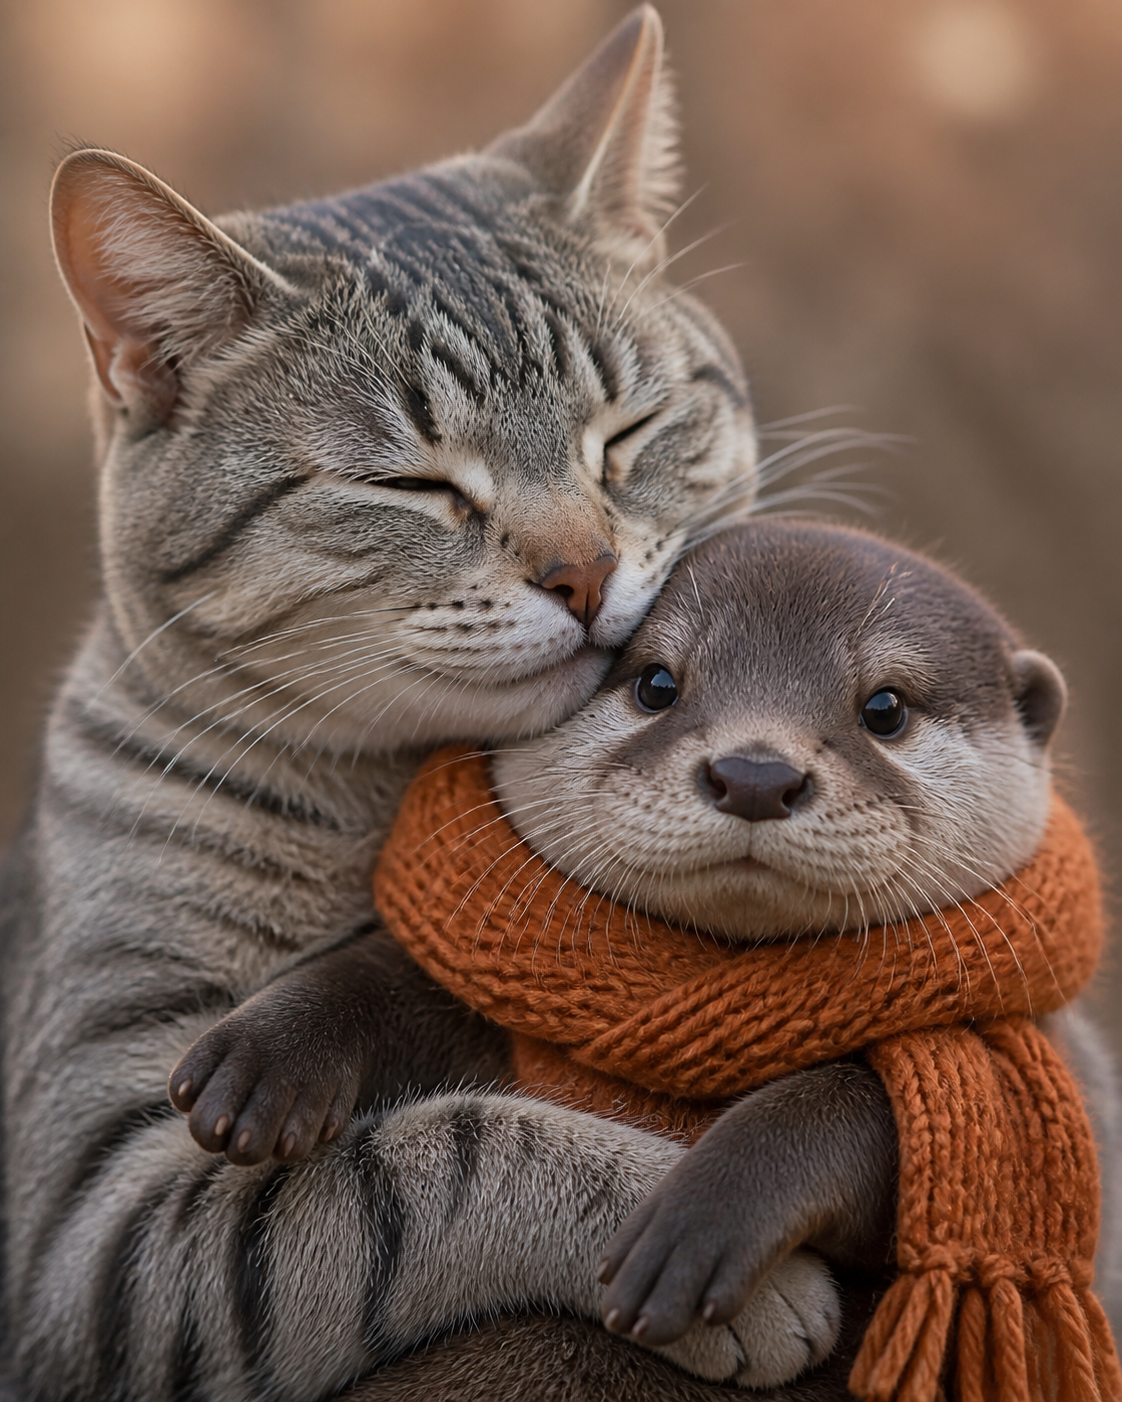

In [37]:
case_number = 34

prompt = use_cases[case_number]

image = generate_image(
    prompt=prompt,
    filename=f"use_case_{case_number}.png"
)